# Artificial Intelligence Course - Fall 1402
## Computer Assignment #5 - CNNs
### provided by: Mohamad Amin Yousefi
#### SID: 810100236

## Problem Description
In this project, we're using a dataset of brain MRI images categorized into four classes: `glioma`, `meningioma`, `notumor`, and `pituitary`. Our aim is to train a Convolutional Neural Network (CNN) to predict whether a patient has a brain tumor or not based on new MRI scans. The model learns from the provided dataset to distinguish between different tumor types and cases without tumors, offering a practical tool for quick and accurate diagnostics in healthcare.

## Imports

In [111]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import os
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import random
from torch.utils.data import random_split, DataLoader, Subset, ConcatDataset
import torch.nn as nn
import torch.optim as optim
import sklearn.metrics as sk_metrics
from colorama import Fore, Back, Style, init

## Constants

In [112]:
drive.mount('/content/drive')
root_folder = '/content/drive/MyDrive/AI-CA5-Dataset'
NO_EPOCHS = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LR = 0.001
IMG_SIZE = (512, 512)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Preprocessing

### Pixel normalization

Pixel normalization is a preprocessing step often applied to the input data in various machine learning tasks, especially in computer vision. Here are some pros and cons associated with pixel normalization:

**Pros:**

1. **Improved Convergence:** Normalizing pixel values to a standard range, such as [0, 1] or [-1, 1], can help in faster convergence during the training of neural networks. It avoids issues related to large input value magnitudes, which might slow down the learning process.

2. **Reduced Sensitivity to Scale:** Normalization makes the model less sensitive to the scale of pixel values. This is particularly important when working with images that might have varying pixel intensity ranges. Normalization ensures that the model is more robust across different datasets.

3. **Stabilized Gradients:** Normalization helps stabilize gradients during backpropagation. This can prevent exploding or vanishing gradients, making it easier to train deep neural networks effectively.

4. **Consistent Model Performance:** Normalization ensures that the model's performance is consistent across different images, as it reduces the impact of variations in pixel intensities.

**Cons:**

1. **Information Loss:** In some cases, aggressive normalization may lead to information loss, especially if the original pixel intensity distribution carries meaningful information. Striking the right balance between normalization and preserving important features is crucial.

2. **Task Dependency:** The effectiveness of pixel normalization can vary depending on the specific task and dataset. In some cases, the data might already be within a reasonable range, and aggressive normalization may not bring significant benefits.

3. **Additional Computational Overhead:** While normalization is a common practice, it adds a computational overhead during training. Depending on the size of the dataset and the computational resources available, this overhead may become a factor to consider.

4. **Normalization Strategy Sensitivity:** The choice of normalization strategy (e.g., z-score normalization, min-max scaling) can impact the model differently. The sensitivity of the model to the chosen normalization method needs to be considered based on the characteristics of the data.

To enhance our CNN model's performance, we implement normalization. Using `transforms.ToTensor()` achieves this by normalizing pixel values to a standardized range. This step, integral to converting images to tensors, ensures numerical stability during training and facilitates quicker convergence. In essence, the normalization aids in consistent model interpretation by making it less sensitive to variations in pixel intensity scales.

In [113]:
class BrainMRIDataset(Dataset):
  def __init__(self, root_dir, transform=None):
      self.root_dir = root_dir
      self.transform = transform
      self.classes = os.listdir(root_dir)
      self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
      self.images, self.class_dist = self.load_images()

  def load_images(self):
      images = []
      class_dist = []
      for class_name in self.classes:
          class_path = os.path.join(self.root_dir, class_name)
          class_idx = self.class_to_idx[class_name]
          class_counter = 0
          for filename in os.listdir(class_path):
              img_path = os.path.join(class_path, filename)
              images.append((img_path, class_idx))
              class_counter += 1
          class_dist.append(class_counter)
      return images, class_dist

  def __len__(self):
      return len(self.images)

  def __getitem__(self, idx):
      img_path, label = self.images[idx]
      img = Image.open(img_path).convert("RGB")
      if self.transform:
          img = self.transform(img)
      return img, label

In [114]:
transform = transforms.Compose([
  transforms.Resize(IMG_SIZE),
  # transforms.ColorJitter(brightness=(0.8,1.2), contrast=(0.8,1.2), saturation=(0.8,1.2), hue=0.25),
  transforms.ToTensor(),
  # transforms.Normalize(mean=0.445, std=0.269)
])

dataset = BrainMRIDataset(root_dir=root_folder, transform=transform)

In [115]:
def show_first_n_images_per_class(dataset, n=1):
  classes = dataset.classes
  num_classes = len(classes)
  fig, axs = plt.subplots(n, num_classes, figsize=(num_classes * 2, n * 2))
  to_pil = transforms.ToPILImage()
  for i, class_name in enumerate(classes):
      class_indices = [idx for idx, (_, label) in enumerate(dataset.images) if label == i]
      class_indices = class_indices[:n]
      for j, idx in enumerate(class_indices):
          img_path, _ = dataset[idx]
          img_pil = to_pil(img_path)
          axs[j, i].imshow(np.asarray(img_pil))
          axs[j, i].axis('off')
          if j == 0:
              axs[j, i].set_title(class_name)
  plt.show()

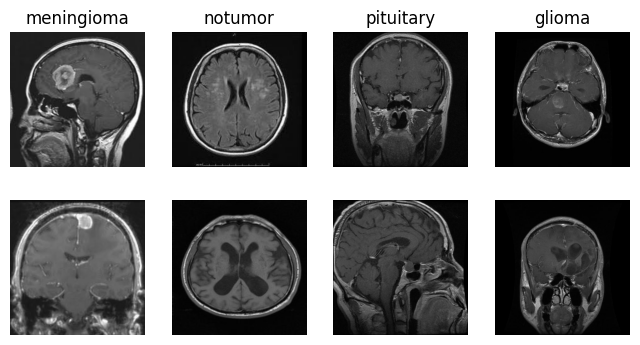

In [116]:
show_first_n_images_per_class(dataset, n=2)

### Train-Test Split

I implemented train-test split using indices and `random.shuffle()`. I split data to $80 \% $ for train and  $20 \%  for test$. I choose these ratios to have enough data for training and testing. Also, I didn't consider a ratio for validation data.

In [117]:
train_datasets, test_datasets = [], []
train_dist, test_dist = [], []

dists = [0] + dataset.class_dist
boundaries = []
for i in range(len(dists)-1):
  boundaries.append((sum(dists[:i+1]), sum(dists[:i+2])))

for class_start, class_end in boundaries:
  class_size = class_end - class_start
  train_size = int(0.8 * class_size)
  train_dist.append(train_size)
  test_dist.append(class_size - train_size)
  indices = list(range(class_start, class_end))
  random.shuffle(indices)
  train_indices = indices[:train_size]
  test_indices = indices[train_size:]
  train_datasets.append(Subset(dataset, train_indices))
  test_datasets.append(Subset(dataset, test_indices))

In [118]:
def plot_dataset_distribution(train_dist, test_dist, class_names):
  classes = np.arange(len(train_dist))
  fig, ax = plt.subplots(figsize=(10, 6))
  bar_width = 0.35
  train_bar = ax.bar(classes, train_dist, bar_width, label='Train')
  test_bar = ax.bar(classes + bar_width, test_dist, bar_width, label='Test')
  ax.set_xlabel('Classes')
  ax.set_ylabel('Number of Samples')
  ax.set_title('Train/Test Dataset Distribution')
  ax.set_xticks(classes + bar_width / 2)
  ax.set_xticklabels(class_names, rotation=45, ha="right")
  ax.legend()
  for i, v in enumerate(train_dist):
      ax.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=8, color='blue')
  for i, v in enumerate(test_dist):
      ax.text(i + bar_width, v + 5, str(v), ha='center', va='bottom', fontsize=8, color='orange')
  plt.show()

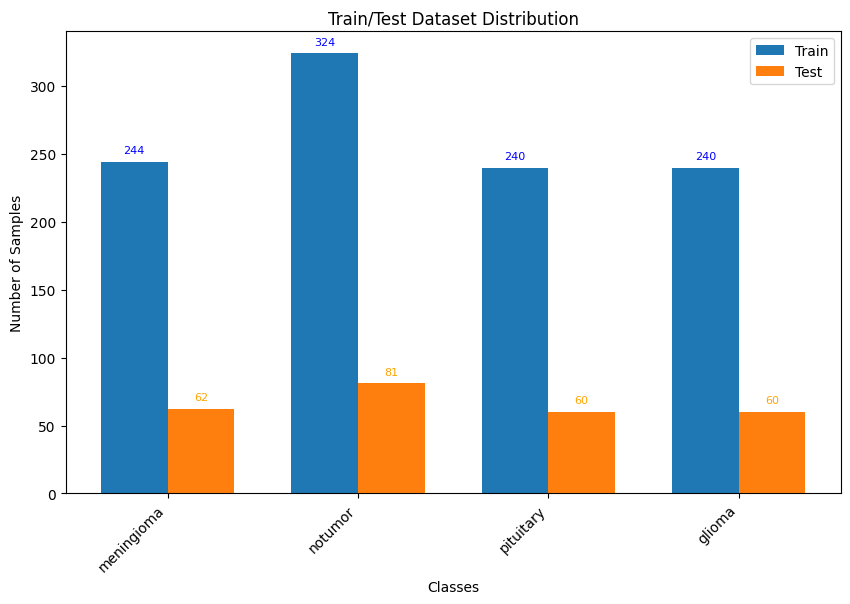

In [119]:
plot_dataset_distribution(train_dist, test_dist, dataset.classes)

## CNN Architecture

CNNs, or Convolutional Neural Networks, are a type of deep learning model designed for processing and analyzing visual data. They excel at capturing hierarchical patterns and features in images through convolutional layers, making them effective for tasks like image recognition and classification.

### 1. `Number of Filters:`
   - Specifies learnable convolutional filters applied to input data.
   - Increases diversity of learned features but raises computational cost and parameters, potentially leading to overfitting.

### 2. `Number of Neurons:`
   - Determines learnable parameters and network capacity.
   - Increasing neurons improves prediction but may lead to overfitting.
   - Too few neurons may result in underfitting.

### 3. `Depth of the Network:`
   - Represents the number of layers in the network.
   - Deeper networks capture more complex and abstract input representations.
   - Challenges include vanishing gradients and increased computational cost.

### 4. `Kernel Size:`
   - Refers to the dimensions of the filter in the convolutional layer.
   - A smaller size captures local patterns, while a larger one captures global information.
   - Impacts the receptive field, influencing the neuron's consideration of context.
   - Larger sizes increase parameters and computational cost.

### 5. `Stride:`
   - Determines the step size during the convolution operation.
   - A larger stride reduces spatial dimensions; a smaller one preserves more spatial information.

### 6. `Padding:`
   - Involves adding extra border pixels before convolution.
   - Types:
      - a. Valid Padding: No padding, convolution on valid input positions.
      - b. Same Padding: Maintains output dimensions by padding to cover the entire input.

### 7. `Activation Functions:`
   - Introduce non-linearity for learning complex relationships.
   - Common functions:
      - a. ReLU: $\ f(x) = max(0, x)$ ; efficient but prone to "dying ReLU" problem.
      - b. Leaky ReLU: $\ f(x) = max(ax, x)$ with a small constant 'a' to address dying ReLU.
      - c. Sigmoid: $\ f(x) = 1 / (1 + e^{-x})$; suitable for binary classification but prone to vanishing gradient.
      - d. Tanh: $\ f(x) = (e^{2x} - 1) / (e^{2x} + 1)$; centered around zero, suitable for normalization.
      - e. Softmax: Used in output layer for multi-class classification, converts real numbers to probability distribution.

Understanding and fine-tuning these parameters is crucial for optimizing neural network performance.

The architecture we're employing takes inspiration from the renowned 'AlexNet,' with several enhancements for better feature extraction and model stability.

- **`Convolutional Layer 1:`** Initiating the process, this layer extracts fundamental features like edges, corners, and textures, utilizing 96 filters sized 11x11 with a stride of 4.

- **`Convolutional Layer 2:`** Progressing beyond basic features, this layer focuses on capturing more intricate and advanced patterns.

- **`Convolutional Layer 3:`** Utilizing 3x3 filters, this layer refines features from the previous stage, extracting abstract information to bolster the model's grasp of complex patterns.

- **`Convolutional Layer 4:`** By applying 3x3 filters to the output from the third convolutional layer, not only does it contribute to pattern recognition, but it also introduces stability to the model.

- **`Convolutional Layer 5:`** Comprising 3x3 filters, this layer delves into extracting even more sophisticated features from the preceding stage.

- **`Fully Connected Layers:`** The final triad of fully connected layers assumes the responsibility of learning high-level representations and making predictions. The first two layers each house 4096 neurons, not only for their predictive prowess but also to enhance the model's stability. The last fully connected layer then produces class probabilities, representing the predicted labels.

- **`Max Pooling Layers:`** Strategically applied to reduce the spatial dimensions of the feature maps, facilitating information retention while mitigating computational complexity.

- **`Average Pooling Layer:`** Serving to further reduce spatial dimensions, this layer streamlines subsequent actions like flattening, effectively preventing potential processing bottlenecks.

- **`Activation Functions:`** The primary activation function here is ReLU, chosen for its simplicity, low computational cost, and its ability to maintain model elegance without unnecessary complexity.

In [120]:
class CNN(nn.Module):
  def __init__(self, num_classes=4):
    super(CNN, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(64, 192, kernel_size=5, padding=2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(192, 384, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(384, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
    )
    self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
    self.classifier = nn.Sequential(
        nn.Linear(256 * 6 * 6, 4096),
        nn.ReLU(inplace=True),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Linear(4096, num_classes),
    )
  def forward(self, x):
    x = self.features(x)
    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.classifier(x)
    # x = torch.nn.functional.softmax(x, dim=1)
    return x

In [121]:
model = CNN().to(device)

### Loss Function

Loss functions in Convolutional Neural Networks (CNNs) play a critical role in training the model by quantifying the difference between predicted values and actual target values. The choice of a suitable loss function depends on the specific nature of the task, such as classification or regression. Here are some commonly used loss functions in CNNs:

1. **Cross-Entropy Loss (or Log Loss):**
   - **Task:** Classification problems with multiple classes.
   - **Use Case:** Commonly used for image classification tasks where the model needs to assign a class label to an input image.
   - **Explanation:** Measures the dissimilarity between predicted probabilities and true class labels. It encourages the model to assign high probabilities to the correct class.
 $$CrossEntropy = - \sum_{i=1}^{C} target_i \log(predicted_i)$$

2. **Mean Squared Error (MSE) Loss:**
   - **Task:** Regression problems where the model predicts continuous values.
   - **Use Case:** Used when the goal is to predict a numerical value, such as age or price.
   - **Explanation:** Computes the average squared difference between predicted and true values. It penalizes larger errors more heavily than smaller ones.
 $$MSE = \frac{1}{n} \sum_{i=1}^{n} ( predicted_i - target_i )^2$$

3. **Binary Cross-Entropy Loss:**
   - **Task:** Binary classification problems.
   - **Use Case:** Applicable when the output is binary (e.g., presence or absence of an object).
   - **Explanation:** Similar to cross-entropy loss but designed for binary classification. It measures the difference between predicted and true binary values.
$$BCE = - \left( target* \log(predicted) + (1 - target) \log(1 - predicted) \right)$$


4. **Categorical Hinge Loss:**
   - **Task:** Multi-class classification problems.
   - **Use Case:** Suitable for classification tasks with multiple classes.
   - **Explanation:** Encourages correct class scores to be higher than incorrect class scores by a margin. Effective when there is a need for a margin between correct and incorrect class predictions.

5. H**uber Loss:**
   - **Task:** Regression problems.
   - **Use Case:** Combines aspects of mean squared error and mean absolute error. It is less sensitive to outliers compared to MSE.
   - **Explanation:** Reduces the impact of outliers by using quadratic loss for small errors and linear loss for larger errors.

6. **Negative Log-Likelihood Loss:**
Computes the negative log-likelihood loss for multi-class classification problems.<br>
Suitable for multi-class classification problems where the targets are class labels.
$$NLLLoss = - \log(predicted_{target})$$

The choice of a loss function is influenced by the nature of the problem at hand and the desired characteristics of the model output. I choose `Cross-Entropy Loss` for several reasons:
It's logarithmic nature provides higher penalties for confident and incorrect predictions, promoting faster and more effective learning. With a natural probabilistic interpretation, it aligns with the goal of maximizing the likelihood of true class probabilities. Cross-Entropy Loss is well-suited for optimization algorithms, mitigating the vanishing gradient problem and ensuring efficient convergence. It extends seamlessly to multi-class problems, works compatibly with softmax activation, and acts as a form of regularization by discouraging overconfident incorrect predictions. While Cross-Entropy Loss is effective, the choice of a loss function depends on specific task characteristics, and experimentation may be needed to find the most suitable one for a given application.

In [122]:
criterion = nn.CrossEntropyLoss()

### Optimizer

Adam, short for Adaptive Moment Estimation, is an optimization algorithm commonly used in training neural networks. It dynamically adjusts learning rates for each parameter based on historical gradients. It incorporates two moments: the mean (capturing the overall gradient trend) and the unbiased variance (capturing gradient variations). Adam initializes and updates these moments during training, with a bias correction mechanism to ensure accurate scaling. Its update rule combines momentum and RMSprop techniques, making it suitable for various neural network architectures and tasks. Adam efficiently handles sparse gradients and converges quickly, but its hyperparameters may require tuning. Overall, it's widely used in practice for its adaptive learning rates and robust performance.

***Comparison With SDG:***

`Adaptability:`
Adam: Adapts learning rates individually for each parameter.
- SGD: Uses a fixed learning rate for all parameters.

`Efficiency:`
- Adam: More computationally expensive.
- SGD: Generally more computationally efficient.

`Sensitivity to Hyperparameters:`
- Adam: Less sensitive, but still requires tuning.
- SGD: Highly sensitive, and finding the right learning rate is crucial.

`Usage:`
- Adam: Commonly used in practice, especially for tasks with large datasets and complex models.
- SGD: Still used, particularly in scenarios where computational resources are limited or in simpler models.

In [123]:
optimizer = optim.Adam(model.parameters(), lr=LR)

### DataLoader and Batchsize

The batch size is a hyperparameter in training Convolutional Neural Network (CNN) models that determines the number of samples processed in each iteration during training. The choice of batch size can have various effects on the training process and the performance of the CNN model. Here are some key considerations:

1. **Computational Efficiency:**
   - **Effect:** Larger batch sizes generally lead to improved computational efficiency. This is because parallel processing capabilities of modern hardware, such as GPUs, can be more effectively utilized when processing larger batches of data simultaneously.
   - **Trade-off:** However, extremely large batch sizes might not fit into GPU memory, limiting the potential for parallelism.

2. **Memory Usage:**
   - **Effect:** Smaller batch sizes reduce the memory requirements during training, which can be crucial for models with limited memory resources. This is especially relevant when working with larger datasets or complex models.
   - **Trade-off:** Larger batch sizes may require more memory, and if the batch size is too large, it might exceed the available GPU memory, leading to out-of-memory errors.

3. **Generalization and Stability:**
   - **Effect:** Smaller batch sizes may introduce more noise into the optimization process, potentially making the training process less stable. However, this can sometimes lead to better generalization, especially when the dataset is small.
   - **Trade-off:** Larger batch sizes provide more stable updates but might lead to a model that is less robust and generalizes less well, especially when the training set is not representative of the overall data distribution.

4. **Convergence Speed:**
   - **Effect:** Larger batch sizes can lead to faster convergence during training due to more accurate gradient estimates. This is often observed in practice, where larger batches can lead to fewer parameter updates per epoch but faster overall training.
   - **Trade-off:** Smaller batch sizes might require more iterations (epochs) to converge, but they might yield better convergence in terms of finding more optimal solutions.


In [124]:
train_loader = DataLoader(ConcatDataset(train_datasets), batch_size=32, shuffle=True)
test_loader = DataLoader(ConcatDataset(test_datasets), batch_size=32, shuffle=False)

In [125]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(NO_EPOCHS):
  correct_train = 0
  total_train = 0
  running_loss = 0.0
  for i,(inputs, labels) in enumerate(train_loader):
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    with torch.set_grad_enabled(True):
      outputs = model(inputs)
    error = criterion(outputs, labels.to(torch.long))
    running_loss += error.item()
    error.backward()
    optimizer.step()

    _, predicted = torch.max(outputs.data, 1)
    total_train += labels.size(0)
    correct_train += (predicted == labels).sum().item()


  train_accuracies.append(100 * correct_train / total_train)
  train_losses.append(running_loss / total_train)
  print(f'Epoch {epoch+1} : ')
  print(f'{Fore.BLUE}\tThe train accuracy : {(100 * correct_train / total_train):.2f} %')
  print(f'{Fore.RED}\tThe train loss : {(running_loss / total_train):.4f}')
  correct_test = 0
  total_test = 0
  running_loss = 0.0

  with torch.no_grad():
    for i,(inputs, labels) in enumerate(test_loader):
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      _, predicted = torch.max(outputs.data, 1)
      total_test += labels.size(0)
      correct_test += (predicted == labels).sum().item()

      error = criterion(outputs, labels.to(torch.long))
      running_loss += error.item()

      del inputs, labels, outputs

  test_accuracies.append(100 * correct_test / total_test)
  test_losses.append(running_loss / total_test)
  print(f'{Fore.BLUE}\tThe test accuracy : {(100 * correct_test / total_test):.2f} %')
  print(f'{Fore.RED}\tThe test loss : {(running_loss / total_test):.4f}')
  print(Style.RESET_ALL)

Epoch 1 : 
	The train accuracy : 27.58 %
	The train loss : 0.0461
	The test accuracy : 30.80 %
	The test loss : 0.0467

Epoch 2 : 
	The train accuracy : 34.64 %
	The train loss : 0.0410
	The test accuracy : 44.87 %
	The test loss : 0.0444

Epoch 3 : 
	The train accuracy : 40.84 %
	The train loss : 0.0379
	The test accuracy : 41.44 %
	The test loss : 0.0404

Epoch 4 : 
	The train accuracy : 45.32 %
	The train loss : 0.0347
	The test accuracy : 47.15 %
	The test loss : 0.0355

Epoch 5 : 
	The train accuracy : 56.87 %
	The train loss : 0.0295
	The test accuracy : 65.02 %
	The test loss : 0.0313

Epoch 6 : 
	The train accuracy : 66.41 %
	The train loss : 0.0239
	The test accuracy : 66.16 %
	The test loss : 0.0254

Epoch 7 : 
	The train accuracy : 69.56 %
	The train loss : 0.0218
	The test accuracy : 67.30 %
	The test loss : 0.0247

Epoch 8 : 
	The train accuracy : 67.65 %
	The train loss : 0.0222
	The test accuracy : 69.20 %
	The test loss : 0.0238

Epoch 9 : 
	The train accuracy : 71.95 %

In [126]:
def plot_metric_vs_epoch(train_metric, test_metric, metric_name, epochs):
  fig, ax = plt.subplots(figsize=(7, 6))
  ax.plot(range(1, epochs+1), train_metric, label="Train " + metric_name, color="blue", marker="o")
  ax.plot(range(1, epochs+1), test_metric, label="Test " + metric_name, color="orange", marker="o")
  ax.set_xlabel('Epoch')
  ax.set_ylabel(metric_name)
  ax.set_title(f'{metric_name} vs Epoch')
  ax.legend()
  ax.grid()
  plt.tight_layout()
  plt.show()

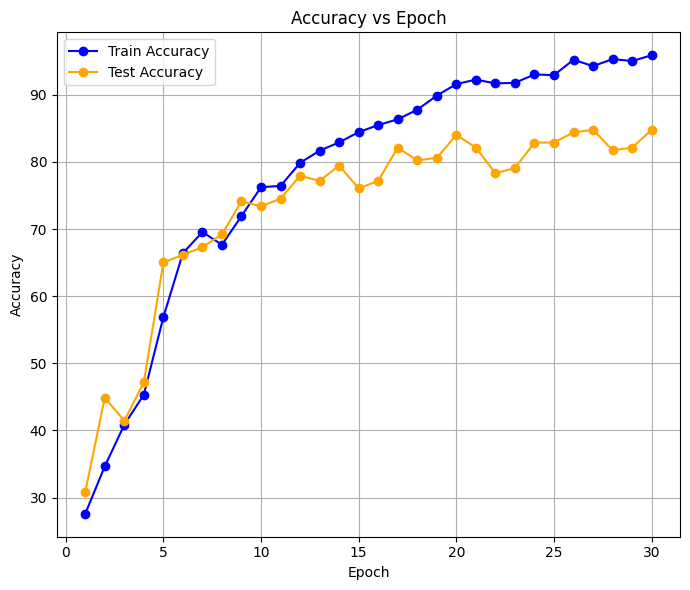

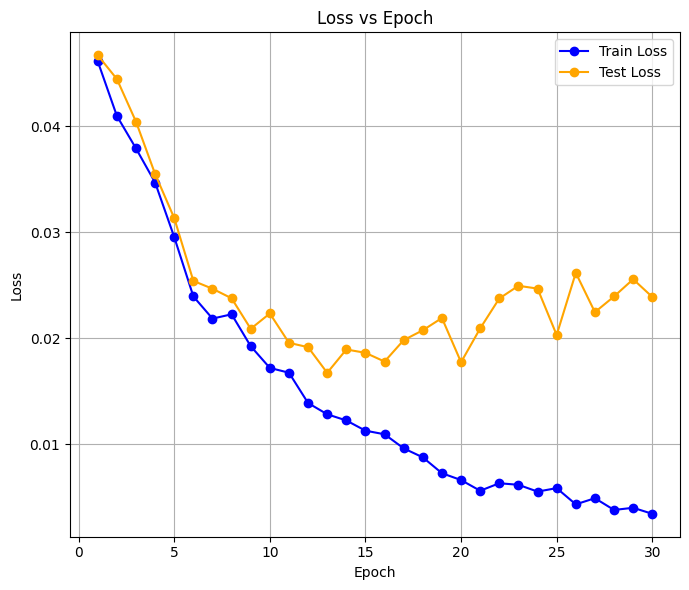

In [127]:
plot_metric_vs_epoch(train_accuracies, test_accuracies, "Accuracy", NO_EPOCHS)
plot_metric_vs_epoch(train_losses, test_losses, "Loss", NO_EPOCHS)

### Regualrization

Batch Normalization and Dropout are regularization techniques commonly used in neural networks, including Convolutional Neural Networks (CNNs), to improve training stability, generalization, and overall model performance.

There are several common ways to implement regularization in machine learning:

1. `L1 Regularization`: This adds a penalty term to the loss function that is proportional to the absolute value of the weights. L1 regularization encourages the model to have sparse weights, meaning that many of the weights are set to zero. This can help simplify the model and prevent overfitting.

2. `L2 Regularization`: This adds a penalty term to the loss function that is proportional to the square of the weights. L2 regularization encourages the model to have small weights, which can also help prevent overfitting. L2 regularization is also known as weight decay.

3. `Dropout`: It works by randomly dropping out (i.e., setting to zero) some of the neurons during training. Dropout encourages the network to learn redundant representations of the data, which can help prevent overfitting.

4. `Early Stopping`: This is a technique used to prevent overfitting by stopping the training process early, before the model has a chance to memorize the training data. Early stopping involves monitoring the performance of the model on a validation set during training and stopping the training process when the performance on the validation set starts to degrade.

5. `Data Augmentation`: In this technique we increase the size of the training set. Data augmentation involves applying random transformations to the training data, such as rotating, scaling, or flipping the images. This can help the model learn more robust representations of the data and prevent overfitting.

6. `Batch Normalization`: The idea behind batch normalization is to normalize the inputs to each layer of the network, so that the distribution of inputs is more stable and consistent across the layers. This helps to prevent the "internal covariate shift" problem, where the distribution of inputs to each layer changes during training, making it harder for the network to learn.

#### `Batch Normalization:`

**Purpose:**
- **Normalization:** Batch Normalization normalizes the input of each layer across a mini-batch. It ensures that the mean activation is close to zero, and the standard deviation is close to one, stabilizing the training process.
- **Internal Covariate Shift:** Batch Normalization helps mitigate the "internal covariate shift," a phenomenon where the distribution of layer activations changes during training, which can slow down convergence.

**Concepts:**
1. **Normalization Steps:**
   - For each mini-batch during training, Batch Normalization normalizes the input by subtracting the batch mean and dividing by the batch standard deviation.
   - It then scales and shifts the normalized values using learnable parameters (gamma and beta) to reintroduce model capacity.

2. **Parameters:**
   - Learnable parameters (gamma and beta) are introduced to allow the model to adapt and learn the most suitable scale and shift for the normalized activations.

3. **Training vs. Inference:**
   - During training, Batch Normalization normalizes based on the statistics of the current mini-batch.
   - During inference, it uses the running statistics (mean and variance) computed during training to normalize input.

**Benefits:**
- **Stabilizes Training:** Batch Normalization helps mitigate vanishing or exploding gradients, allowing for more stable and faster training.
- **Regularization Effect:** Acts as a form of regularization by adding noise to the mini-batch, reducing overfitting.

#### `Dropout:`

**Purpose:**
- **Regularization:** Dropout is a regularization technique aimed at preventing overfitting by randomly dropping out (setting to zero) a fraction of the units/neurons during training.

**Key Concepts:**
1. **Random Dropout:**
   - During each training iteration, a random fraction of neurons is set to zero. This fraction is typically a hyperparameter set before training.

2. **Inference without Dropout:**
   - During inference, all neurons are active, but their weights are scaled by the dropout rate. This scaling ensures that the expected output during inference remains consistent with the training phase.

**Benefits:**
- **Reduces Overfitting:** Dropout introduces a form of model averaging during training, preventing the network from relying too much on specific neurons and features.
- **Ensemble Effect:** Each dropout configuration during training can be seen as training a different model, and combining these models during inference provides an ensemble effect.

**Comparison:**
- **Complementary Techniques:** Batch Normalization and Dropout are often used together as they serve complementary purposes. Batch Normalization stabilizes training by normalizing activations, while Dropout acts as a regularizer by preventing overfitting.
- **Training Dynamics:** Batch Normalization influences the internal dynamics of the network during each training iteration, while Dropout introduces variability in the network's structure by randomly dropping out units.

In [128]:
class RegularizedCNN(nn.Module):
  def __init__(self, num_classes=4):
    super(RegularizedCNN, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(64, 192, kernel_size=5, padding=2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(192, 384, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(384, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
    )
    self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
    self.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(256 * 6 * 6, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Linear(4096, num_classes),
    )
  def forward(self, x):
    x = self.features(x)
    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.classifier(x)
    return x

For the `batch size` parameter, it's advisable to set it equal to the number of filters in the Linear layer preceding it. As for the `drop` probability, choosing a high value may lead to underfitting, limiting the model's ability to grasp intricate patterns in the data. Conversely, a low probability may hinder effective regularization, potentially causing overfitting. Therefore, I've opted for a probability of $0.2$ as a balanced choice.

In [129]:
model = RegularizedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [130]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(NO_EPOCHS):
  correct_train = 0
  total_train = 0
  running_loss = 0.0
  for i,(inputs, labels) in enumerate(train_loader):
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    with torch.set_grad_enabled(True):
      outputs = model(inputs)
    error = criterion(outputs, labels.to(torch.long))
    running_loss += error.item()
    error.backward()
    optimizer.step()

    _, predicted = torch.max(outputs.data, 1)
    total_train += labels.size(0)
    correct_train += (predicted == labels).sum().item()

  train_accuracies.append(100 * correct_train / total_train)
  train_losses.append(running_loss / total_train)
  print(f'Epoch {epoch+1} :')
  print(f'{Fore.BLUE}\tThe train accuracy : {(100 * correct_train / total_train):.2f} %')
  print(f'{Fore.RED}\tThe train loss : {(running_loss / total_train):.4f}')
  correct_test = 0
  total_test = 0
  running_loss = 0.0
  with torch.no_grad():
    for i,(inputs, labels) in enumerate(test_loader):
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      _, predicted = torch.max(outputs.data, 1)
      total_test += labels.size(0)
      correct_test += (predicted == labels).sum().item()

      error = criterion(outputs, labels.to(torch.long))
      running_loss += error.item()

  test_accuracies.append(100 * correct_test / total_test)
  test_losses.append(running_loss / total_test)
  print(f'{Fore.BLUE}\tThe test accuracy : {(100 * correct_test / total_test):.2f} %')
  print(f'{Fore.RED}\tThe test loss : {(running_loss / total_test):.4f}')
  print(Style.RESET_ALL)

Epoch 1 :
	The train accuracy : 25.00 %
	The train loss : 0.0457
	The test accuracy : 30.80 %
	The test loss : 0.0469

Epoch 2 :
	The train accuracy : 31.20 %
	The train loss : 0.0428
	The test accuracy : 39.92 %
	The test loss : 0.0440

Epoch 3 :
	The train accuracy : 36.83 %
	The train loss : 0.0400
	The test accuracy : 47.15 %
	The test loss : 0.0415

Epoch 4 :
	The train accuracy : 39.41 %
	The train loss : 0.0400
	The test accuracy : 43.35 %
	The test loss : 0.0408

Epoch 5 :
	The train accuracy : 51.62 %
	The train loss : 0.0348
	The test accuracy : 58.56 %
	The test loss : 0.0341

Epoch 6 :
	The train accuracy : 53.05 %
	The train loss : 0.0324
	The test accuracy : 63.88 %
	The test loss : 0.0308

Epoch 7 :
	The train accuracy : 57.82 %
	The train loss : 0.0301
	The test accuracy : 53.23 %
	The test loss : 0.0322

Epoch 8 :
	The train accuracy : 67.18 %
	The train loss : 0.0225
	The test accuracy : 68.82 %
	The test loss : 0.0235

Epoch 9 :
	The train accuracy : 73.47 %
	The tra

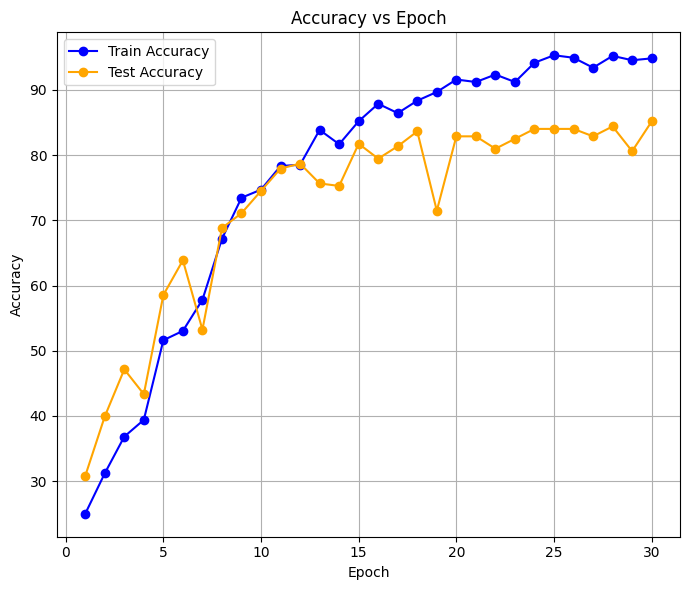

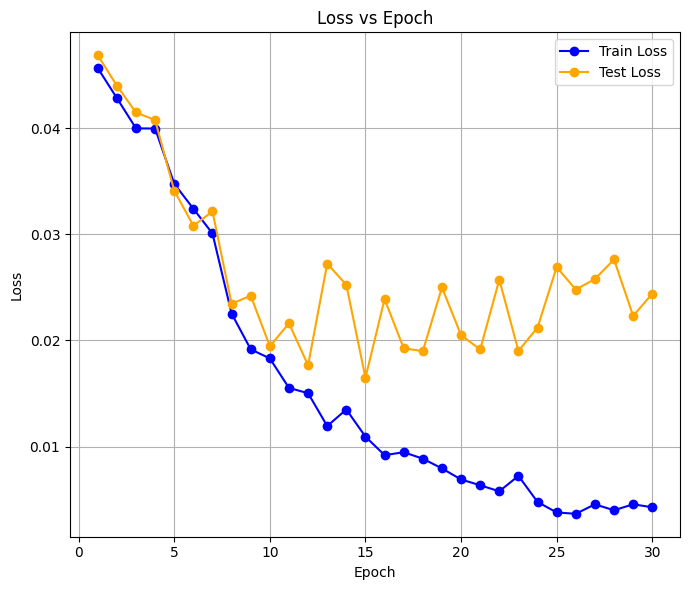

In [131]:
plot_metric_vs_epoch(train_accuracies, test_accuracies, "Accuracy", NO_EPOCHS)
plot_metric_vs_epoch(train_losses, test_losses, "Loss", NO_EPOCHS)

I only used `Dropout` because `BatchNorm2d` adds a considerable noise and has bad effect on accuracy.

The model already performed good without regularization but after adding it the accuracies have became closer.

In [137]:
def plot_conf_matrix(conf_matrix, class_labels):
  plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.YlGn)
  plt.title('Confusion Matrix')
  plt.colorbar()
  plt.xticks(np.arange(len(class_labels)), class_labels)
  plt.yticks(np.arange(len(class_labels)), class_labels)
  for i in range(len(class_labels)):
      for j in range(len(class_labels)):
          plt.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', color='black')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.show()

def seprate_data(y_pred, y_true, class_maps, label):
  seprated_y_true = []
  seprated_y_preds = []
  for i in range(len(y_true)):
      if y_true[i] == class_maps[label]:
          seprated_y_true.append(1)
      else:
          seprated_y_true.append(0)
      if y_pred[i] == class_maps[label]:
          seprated_y_preds.append(1)
      else:
          seprated_y_preds.append(0)
  return np.array(seprated_y_true), np.array(seprated_y_preds)

def calc_metrics(y_true, y_pred, dataset):
  y_true = np.array(y_true)
  y_pred = np.array(y_pred)
  print(f"Accuracy of the CNN is {100 * sk_metrics.accuracy_score(y_true, y_pred):.3f} %")
  print(f"Precision of the model is {100 * sk_metrics.precision_score(y_true, y_pred, average='macro'):.3f}%")
  print(f"Recall of the model is {100 * sk_metrics.recall_score(y_true, y_pred, average='macro'):.3f}%")
  print(f"F1_score of the model is {100 * sk_metrics.f1_score(y_true, y_pred, average='macro'):.3f}%\n")
  print("We calculate metrics for each class:\n")

  for class_label in dataset.classes:
    seprated_y_true, seprated_y_preds = seprate_data(y_pred, y_true, dataset.class_to_idx, class_label)
    print(f"\tAccuracy for type {class_label} is {100 * sk_metrics.accuracy_score(seprated_y_true, seprated_y_preds):.3f} %")
    print(f"\tPrecision for type {class_label} is {100 * sk_metrics.precision_score(seprated_y_true, seprated_y_preds):.3f} %")
    print(f"\tRecall for type {class_label} is {100 * sk_metrics.recall_score(seprated_y_true, seprated_y_preds):.3f} %")
    print(f"\tF1_score for type {class_label} is {100 * sk_metrics.f1_score(seprated_y_true, seprated_y_preds):.3f} %\n")
  plot_conf_matrix(sk_metrics.confusion_matrix(y_true, y_pred), dataset.classes)

Accuracy of the CNN is 86.692 %
Precision of the model is 86.423%
Recall of the model is 86.064%
F1_score of the model is 86.071%

We calculate metrics for each class:

	Accuracy for type meningioma is 86.692 %
	Precision for type meningioma is 70.769 %
	Recall for type meningioma is 74.194 %
	F1_score for type meningioma is 72.441 %

	Accuracy for type notumor is 97.338 %
	Precision for type notumor is 96.250 %
	Recall for type notumor is 95.062 %
	F1_score for type notumor is 95.652 %

	Accuracy for type pituitary is 95.437 %
	Precision for type pituitary is 86.364 %
	Recall for type pituitary is 95.000 %
	F1_score for type pituitary is 90.476 %

	Accuracy for type glioma is 93.916 %
	Precision for type glioma is 92.308 %
	Recall for type glioma is 80.000 %
	F1_score for type glioma is 85.714 %



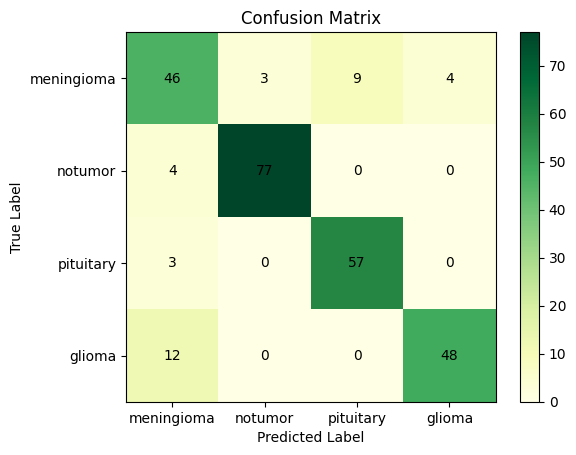

In [139]:
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for i,(inputs, labels) in enumerate(test_loader):
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      _, predicted = torch.max(outputs.data, 1)
      y_true += [_.item() for _ in list(labels)]
      y_pred += [_.item() for _ in list(predicted)]
calc_metrics(np.array(y_true),np.array(y_pred), dataset)